# ADD TO FIGURE 3 NOTEBOOK

In [40]:
import fitness_landscape as fl
from fitness_landscape.utils import fasta_to_prot20_sequences
from fitness_landscape.core.landscape import FitnessLandscape
from fitness_landscape.transforms.eigenmode import eigenmode_decomposition
from collections import defaultdict
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import re
import pickle
import json
from tqdm import tqdm
import networkx as nx
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import spearmanr
from scipy.stats import norm
import matplotlib as mpl

ModuleNotFoundError: No module named 'statsmodels'

### Solution space size and ruggedness

In [2]:
n_params = range(4,11)
seeds = range(10)
rows = []

for _, seed in tqdm(enumerate(seeds)):
    for n_value in n_params:
        
        # Iterate through K parameters
        for k_value in range(0, n_value):

            nk = fl.models.create_nk_binary_landscape(N=n_value, K=k_value, seed=seed)

            layer = nk.view(f"nk_k={k_value}")  # active by default, but explicit is safe
            fitness = layer.to_scalar()
            
            # Parititon f_min as the mean fitness
            mean_fitness = float(fitness.mean())
            solution_mask = fitness > mean_fitness

            # Attach categorical layer for the solution set
            labels = np.where(solution_mask, "solution", "non_solution").tolist()
            nk.attach(
                name="solution_set",
                values=labels,
                dtype="categorical",
                categories=["non_solution", "solution"],
            )

            # Conductance of the solution set
            G = nk.graph
            node_order = list(G.nodes())
            solution_nodes = [node_order[i] for i, is_sol in enumerate(solution_mask) if is_sol]
            phi = nx.algorithms.cuts.conductance(G, solution_nodes, weight="weight")
            
            # tmap on landscape
            layer = nk.view(f"nk_k={k_value}")
            tmap_res = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(nk, t_min=1e-10, t_max=1e2)
            tmap = float(tmap_res.get("t_map", np.nan))
            tmap_upper_ci = float(tmap_res.get("t_upper_confidence_interval", np.nan))
            tmap_lower_ci = float(tmap_res.get("t_lower_confidence_interval", np.nan))

            res = {
                "seed": seed,
                "N" : n_value,
                "K" : k_value,
                "conductance" : phi,
                "tmap" : tmap,
                "tmap_lower_ci" : tmap_lower_ci,
                "tmap_upper_ci" : tmap_upper_ci,
            }

            rows.append(res)

df = pd.DataFrame(rows)

10it [05:18, 31.86s/it]


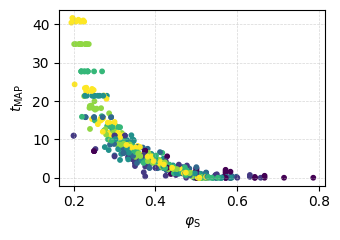

In [4]:
plt.figure(figsize=(3.5, 2.5))

plt.scatter(df['conductance'], df['tmap'], c=df['N'], s=10, alpha=1)
plt.ylabel(r"$t_{\mathrm{MAP}}$")
plt.xlabel(r"$φ_{\mathrm{S}}$")
plt.tight_layout()
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
plt.savefig('../figures/figure_3/conductance_S_vs_tmap.pdf')
plt.show()

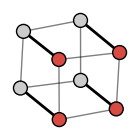

In [63]:
n_value = 3
k_value = 0
seed = 4

nk = fl.models.create_nk_binary_landscape(N=n_value, K=k_value, seed=seed)

layer = nk.view(f"nk_k={k_value}")  # active by default, but explicit is safe
fitness = layer.to_scalar()

# Parititon f_min as the mean fitness
mean_fitness = float(fitness.mean())
solution_mask = fitness > mean_fitness

# Attach categorical layer for the solution set
labels = np.where(solution_mask, "solution", "non_solution").tolist()
nk.attach(
    name="solution_set",
    values=labels,
    dtype="categorical",
    categories=["non_solution", "solution"],
)
nk.view("solution_set")


G = nk.graph
node_order = list(G.nodes())

# Build node -> solution label map
solution_nodes = set(node_order[i] for i, is_sol in enumerate(solution_mask) if is_sol)

node_class = {
    node: ("solution" if node in solution_nodes else "non_solution")
    for node in node_order
}

# Split edges into boundary vs interior
boundary_edges = []
interior_edges = []

for u, v in G.edges():
    if node_class[u] != node_class[v]:
        boundary_edges.append((u, v))
    else:
        interior_edges.append((u, v))

# Layout (spring is fine for small NK graphs)
pos = nx.spring_layout(G, seed=1)

# Node colors
node_colors = [
    "#d84b43" if node in solution_nodes else "#cccccc"
    for node in G.nodes()
]

plt.figure(figsize=(1.5, 1.5))

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=100,
    edgecolors="black"
)

# Draw interior edges (thin)
nx.draw_networkx_edges(
    G, pos,
    edgelist=interior_edges,
    width=1.,
    alpha=0.5,
    edge_color="black"
)

# Draw boundary edges (bold)
nx.draw_networkx_edges(
    G, pos,
    edgelist=boundary_edges,
    width=2.0,
    alpha=1.0,
    edge_color="black"
)

plt.axis("off")
plt.tight_layout()
plt.savefig('../figures/figure_3/nk_k=0_epsilonS.pdf')
plt.show()

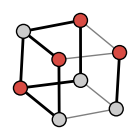

In [ ]:
n_value = 3
k_value = 2
seed = 4

nk = fl.models.create_nk_binary_landscape(N=n_value, K=k_value, seed=seed)

layer = nk.view(f"nk_k={k_value}")  # active by default, but explicit is safe
fitness = layer.to_scalar()

# Parititon f_min as the mean fitness
mean_fitness = float(fitness.mean())
solution_mask = fitness > mean_fitness

# Attach categorical layer for the solution set
labels = np.where(solution_mask, "solution", "non_solution").tolist()
nk.attach(
    name="solution_set",
    values=labels,
    dtype="categorical",
    categories=["non_solution", "solution"],
)
nk.view("solution_set")


G = nk.graph
node_order = list(G.nodes())

# Build node -> solution label map
solution_nodes = set(node_order[i] for i, is_sol in enumerate(solution_mask) if is_sol)

node_class = {
    node: ("solution" if node in solution_nodes else "non_solution")
    for node in node_order
}

# Split edges into boundary vs interior
boundary_edges = []
interior_edges = []

for u, v in G.edges():
    if node_class[u] != node_class[v]:
        boundary_edges.append((u, v))
    else:
        interior_edges.append((u, v))

# Layout (spring is fine for small NK graphs)
pos = nx.spring_layout(G, seed=1)

# Node colors
node_colors = [
    "#d84b43" if node in solution_nodes else "#cccccc"
    for node in G.nodes()
]

plt.figure(figsize=(1.5, 1.5))

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=100,
    edgecolors="black"
)

# Draw interior edges (thin)
nx.draw_networkx_edges(
    G, pos,
    edgelist=interior_edges,
    width=1.,
    alpha=0.5,
    edge_color="black"
)

# Draw boundary edges (bold)
nx.draw_networkx_edges(
    G, pos,
    edgelist=boundary_edges,
    width=2.0,
    alpha=1.0,
    edge_color="#E8A838"
)

plt.axis("off")
plt.tight_layout()
plt.savefig('../figures/figure_3/nk_k=2_epsilonS.pdf')
plt.show()

### Diagram plot of interacting fitness functions and solution spaces

Saved ../figures/figure_3/intersection_1D_slice.pdf


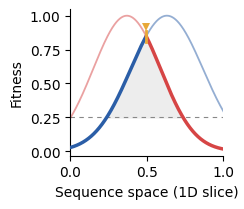

Saved ../figures/figure_3/intersection_2D_solution_space.pdf


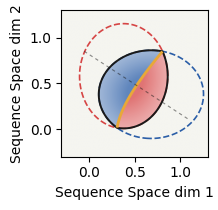

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
from scipy.optimize import brentq


C_RED    = "#D64545"   # constraint 1 (e.g., folding)
C_BLUE   = "#2B5EA7"   # constraint 2 (e.g., binding)
C_GOLD   = "#E8A838"   # switching boundary
C_BLACK  = "#1a1a1a"
C_MUTED  = "#888888"
C_VIABLE = "#ededed"
C_BG     = "#F5F5F0"

# RGB base arrays for the two constraints
RGB_RED  = np.array([214, 69, 69]) / 255.0
RGB_BLUE = np.array([43, 94, 167]) / 255.0


# ── Shared 2D fitness functions (ground truth for both panels) ──
# Each constraint has a smooth elliptical solution set, but fitness rises
# exponentially toward each center. Because the centers are offset and the
# gradients point in different directions, the min creates a sharp ridge
# along the switching boundary.

def f1_2d(x, y):
    """Constraint 1 (folding): steep exponential peak centered left-up."""
    r2 = (x - 0.38)**2 * 1.2 + (y - 0.58)**2 * 0.85
    return np.exp(-5.0 * r2)

def f2_2d(x, y):
    """Constraint 2 (binding): steep exponential peak centered right-down."""
    r2 = (x - 0.68)**2 * 0.85 + (y - 0.38)**2 * 1.2
    return np.exp(-5.0 * r2)

THRESHOLD = 0.25

# ── 1D functions derived as a diagonal slice through 2D landscape ──
SLICE_START = np.array([-0.05, 0.85])
SLICE_END   = np.array([1.10, 0.10])

def _slice_point(t):
    """Map parameter t in [0,1] to a point on the diagonal slice."""
    return SLICE_START + t * (SLICE_END - SLICE_START)

def f1_1d(t):
    """Constraint 1 evaluated along the diagonal slice."""
    p = _slice_point(t)
    return f1_2d(p[0], p[1])

def f2_1d(t):
    """Constraint 2 evaluated along the diagonal slice."""
    p = _slice_point(t)
    return f2_2d(p[0], p[1])

# Vectorized versions
def f1_1d_vec(t):
    p = SLICE_START[:, None] + t[None, :] * (SLICE_END - SLICE_START)[:, None]
    return f1_2d(p[0], p[1])

def f2_1d_vec(t):
    p = SLICE_START[:, None] + t[None, :] * (SLICE_END - SLICE_START)[:, None]
    return f2_2d(p[0], p[1])


# ── View range for the 2D panel ──
VIEW_PAD = 0.3
VIEW_MIN = -VIEW_PAD
VIEW_MAX = 1.0 + VIEW_PAD


def make_panel_D(ax=None, save_path="panel_D.pdf"):
    """
    2D sequence space heatmap.
    Viable region colored by limiting constraint (red vs blue).
    Switching boundary in gold. Individual constraint boundaries dashed.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(2.5, 2.2))
        standalone = True
    else:
        fig = ax.figure
        standalone = False

    res = 500
    x = np.linspace(VIEW_MIN, VIEW_MAX, res)
    y = np.linspace(VIEW_MIN, VIEW_MAX, res)
    X, Y = np.meshgrid(x, y)

    F1 = f1_2d(X, Y)
    F2 = f2_2d(X, Y)
    F_min = np.minimum(F1, F2)

    viable = F_min >= THRESHOLD
    limiter = np.argmin(np.stack([F1, F2], axis=-1), axis=-1)  # 0=red-limited, 1=blue-limited

    # Build RGBA image
    img = np.ones((res, res, 4))
    img[..., :3] = np.array([245, 245, 240]) / 255.0  # non-viable background

    for idx, rgb_base in enumerate([RGB_RED, RGB_BLUE]):
        mask = viable & (limiter == idx)
        brightness = np.clip(0.6 + 0.4 * (F_min - THRESHOLD) / 0.5, 0, 1)
        for c in range(3):
            img[..., c] = np.where(
                mask,
                rgb_base[c] * brightness + (1 - brightness) * 1.0,
                img[..., c],
            )
    img[viable, 3] = 0.75
    img[~viable, 3] = 1.0

    ax.imshow(img, origin="lower", extent=[VIEW_MIN, VIEW_MAX, VIEW_MIN, VIEW_MAX],
              aspect="equal", interpolation="bilinear")

    # ── Individual constraint boundaries (dashed contours) ──
    ax.contour(X, Y, F1, levels=[THRESHOLD], colors=[C_RED],
               linewidths=1.2, linestyles="dashed")
    ax.contour(X, Y, F2, levels=[THRESHOLD], colors=[C_BLUE],
               linewidths=1.2, linestyles="dashed")

    # ── Composite viable boundary (solid dark) ──
    ax.contour(X, Y, F_min, levels=[THRESHOLD], colors=[C_BLACK],
               linewidths=1.4, linestyles="solid")

    # ── Switching boundary (where F1 ≈ F2 inside viable region) ──
    diff = F1 - F2
    diff_masked = np.where(viable, diff, np.nan)
    # Draw switching boundary only within viable region
    cs = ax.contour(X, Y, diff_masked, levels=[0], colors=[C_GOLD],
                    linewidths=2.0, linestyles="solid")

    # ── Draw the 1D slice line (dashed, thin) to connect to panel C ──
    ax.plot([SLICE_START[0], SLICE_END[0]], [SLICE_START[1], SLICE_END[1]],
            color=C_BLACK, lw=0.8, ls=(0, (3, 3)), alpha=0.5, zorder=6)
    # Small label for the slice
    mid = _slice_point(0.5)
    angle = np.degrees(np.arctan2(SLICE_END[1] - SLICE_START[1],
                                   SLICE_END[0] - SLICE_START[0]))
    # ax.text(mid[0] + 0.06, mid[1] + 0.06, "1D slice", fontsize=5.5,
    #         color=C_MUTED, ha="center", va="bottom", rotation=angle,
    #         fontstyle="italic")

    # ── Labels ──
    ax.set_xlabel("Sequence Space dim 1")
    ax.set_ylabel("Sequence Space dim 2")
    ax.set_xticks([0, 0.5, 1.0])
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_xlim(VIEW_MIN, VIEW_MAX)
    ax.set_ylim(VIEW_MIN, VIEW_MAX)

    if standalone:
        fig.tight_layout()
        fig.savefig(save_path, bbox_inches="tight")
        print(f"Saved {save_path}")
        plt.show()

    return ax


def make_panel_C(ax=None, save_path="panel_C.pdf"):
    """
    1D cross-section through sequence space — a diagonal slice through the 2D landscape.
    Two smooth fitness functions, their piecewise minimum,
    viable region shaded, switching points marked.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(2.5, 2.2))
        standalone = True
    else:
        fig = ax.figure
        standalone = False

    t = np.linspace(0, 1, 2000)
    y1 = f1_1d_vec(t)
    y2 = f2_1d_vec(t)
    y_min = np.minimum(y1, y2)
    threshold = THRESHOLD

    # ── Shade viable region (under composite, above threshold) ──
    viable_mask = y_min >= threshold
    ax.fill_between(t, threshold, y_min, where=viable_mask,
                    color=C_VIABLE, zorder=1)

    # ── Individual constraint curves (semi-transparent) ──
    ax.plot(t, y1, color=C_RED, lw=1.3, alpha=0.5, label="$f_1$ (folding)", zorder=2)
    ax.plot(t, y2, color=C_BLUE, lw=1.3, alpha=0.5, label="$f_2$ (binding)", zorder=2)

    # ── Composite min curve (bold) ──
    limiter = np.argmin(np.stack([y1, y2]), axis=0)
    segment_colors = [C_RED, C_BLUE]

    changes = np.where(np.diff(limiter) != 0)[0]
    boundaries = np.concatenate([[0], changes + 1, [len(t)]])
    for i in range(len(boundaries) - 1):
        sl = slice(boundaries[i], boundaries[i + 1])
        ax.plot(t[sl], y_min[sl], color=segment_colors[limiter[boundaries[i]]],
                lw=2.5, zorder=4, solid_capstyle="round")

    # ── Threshold line ──
    ax.axhline(threshold, color=C_MUTED, lw=0.8, ls=(0, (4, 4)), zorder=1)
    # ax.text(-0.03, threshold, "$f_{\\mathrm{min}}$", fontsize=8, color=C_MUTED,
    #         ha="right", va="center")

    # ── Switching points ──
    diff = y1 - y2
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    switch_ts = []
    for idx in sign_changes:
        t0, t1_ = t[idx], t[idx + 1]
        d0, d1 = diff[idx], diff[idx + 1]
        t_cross = t0 - d0 * (t1_ - t0) / (d1 - d0)
        switch_ts.append(t_cross)

    for st in switch_ts:
        sy = min(f1_1d(st), f2_1d(st))
        ax.plot([st, st], [sy - 0.04, sy + 0.04], color=C_GOLD, lw=2.0, zorder=5)
        ax.plot(st, sy + 0.07, marker="v", markersize=6, color=C_GOLD,
                zorder=5, markeredgewidth=0)

    # ── Axes ──
    ax.set_xlabel("Sequence space (1D slice)")
    ax.set_ylabel("Fitness")
    ax.set_xlim(0, 1)
    # ax.set_ylim(-0.6, 1.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if standalone:
        fig.tight_layout()
        fig.savefig(save_path, bbox_inches="tight")
        print(f"Saved {save_path}")
        plt.show()
    return ax

# Generate both panels
make_panel_C(save_path="../figures/figure_3/intersection_1D_slice.pdf")
make_panel_D(save_path="../figures/figure_3/intersection_2D_solution_space.pdf")

plt.show()